# E-Commerce Sales and Profit Analysis

## Project Overview

This project analyzes sales and profit performance using Python and Pandas.

The analysis focuses on identifying sales trends, profitable categories, sub-categories, and customer segments to generate actionable business insights.

### Tools Used
- Python
- Pandas
- Plotly
- Jupyter Notebook

### Dataset
Sample Superstore Dataset

In [1]:
import pandas as pd 

In [82]:
import plotly.express as px  
import plotly.graph_objects as go
import plotly.io as pio
import plotly.colors as colors 
pio.templates.default = "plotly_white" 

In [3]:
data=pd.read_csv("Sample - Superstore.csv",encoding='latin-1')

In [5]:
data.head() 
 

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
data.describe().style.format({
    'Profit': '${:,.2f}',
    'Sales':'${:,.2f}'
}) 

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,"$9,994.00",9994.000000,9994.000000,"$9,994.00"
mean,4997.500000,55190.379428,$229.86,3.789574,0.156203,$28.66
std,2885.163629,32063.693350,$623.25,2.225110,0.206452,$234.26
min,1.000000,1040.000000,$0.44,1.000000,0.000000,"$-6,599.98"
25%,2499.250000,23223.000000,$17.28,2.000000,0.000000,$1.73
50%,4997.500000,56430.500000,$54.49,3.000000,0.200000,$8.67
75%,7495.750000,90008.000000,$209.94,5.000000,0.200000,$29.36
max,9994.000000,99301.000000,"$22,638.48",14.000000,0.800000,"$8,399.98"


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [89]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

In [11]:
data['Order Month']= data['Order Date'].dt.month
data['Order Year']= data['Order Date'].dt.year
data['Order Day of Week']= data['Order Date'].dt.dayofweek


## Monthly Sales Analysis

In [13]:
sales_by_month = data.groupby('Order Month')['Sales'].sum().reset_index()

sales_by_month

,Order Month,Sales
0,1,94924.8356
1,2,59751.2514
2,3,205005.4888
3,4,137762.1286
4,5,155028.8117
5,6,152718.6793
6,7,147238.0970
7,8,159044.0630
8,9,307649.9457
9,10,200322.9847


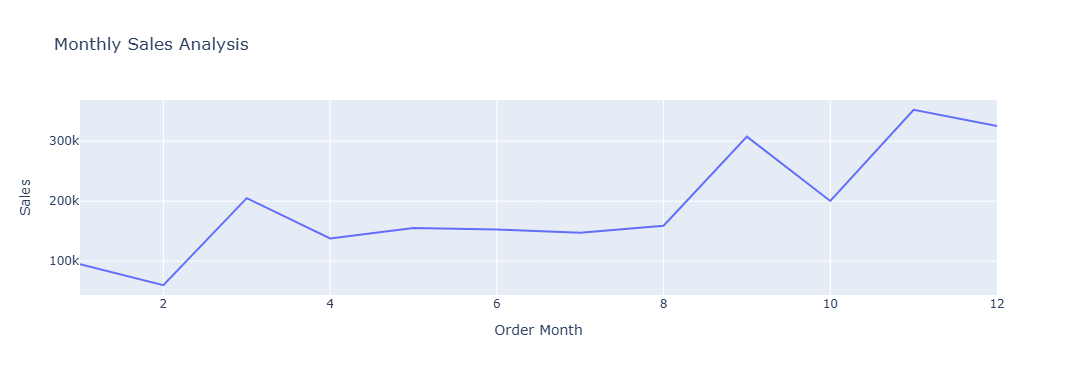

In [15]:
fig = px.line(sales_by_month,
              x='Order Month',
              y='Sales',
              title='Monthly Sales Analysis')



fig.show()

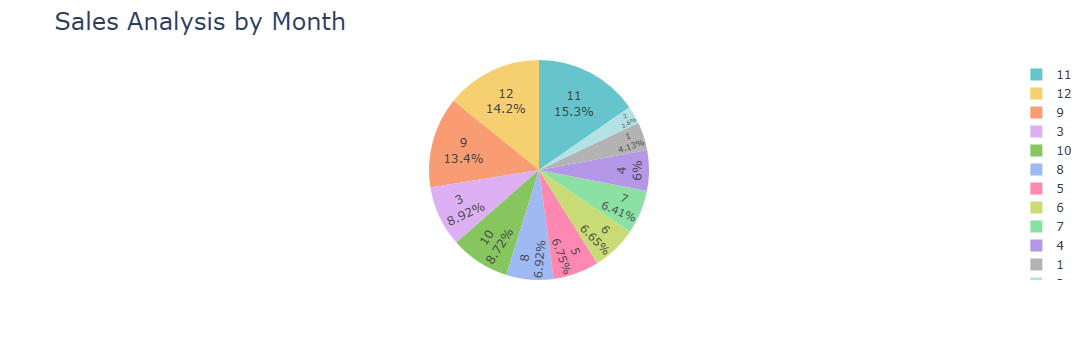

In [83]:
fig2=px.pie(sales_by_month,
            values='Sales',
            names='Order Month',
            hole=0.0,
            color_discrete_sequence=px.colors.qualitative.Pastel)
fig2.update_traces(textposition='inside', textinfo='percent+label')
fig2.update_layout(title_text='Sales Analysis by Month', title_font= dict(size=24))
fig2.show()

## Sales by Category

In [23]:
sales_by_category=data.groupby('Category')['Sales'].sum().reset_index()

In [24]:
sales_by_category

,Category,Sales
0,Furniture,741999.7953
1,Office Supplies,719047.0320
2,Technology,836154.0330


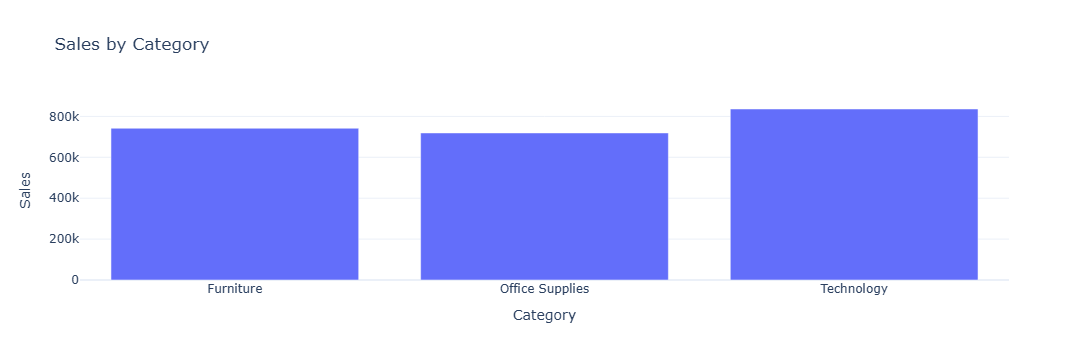

In [90]:
fig = px.bar(
    sales_by_category,
    x='Category',
    y='Sales',
    title='Sales by Category'
)

fig.show()


## Sales Analysis by Sub-Category

In [43]:
sales_by_subcategory=data.groupby('Sub-Category')['Sales'].sum().reset_index()

In [44]:
sales_by_subcategory

,Sub-Category,Sales
0,Accessories,167380.3180
1,Appliances,107532.1610
2,Art,27118.7920
3,Binders,203412.7330
4,Bookcases,114879.9963
5,Chairs,328449.1030
6,Copiers,149528.0300
7,Envelopes,16476.4020
8,Fasteners,3024.2800
9,Furnishings,91705.1640


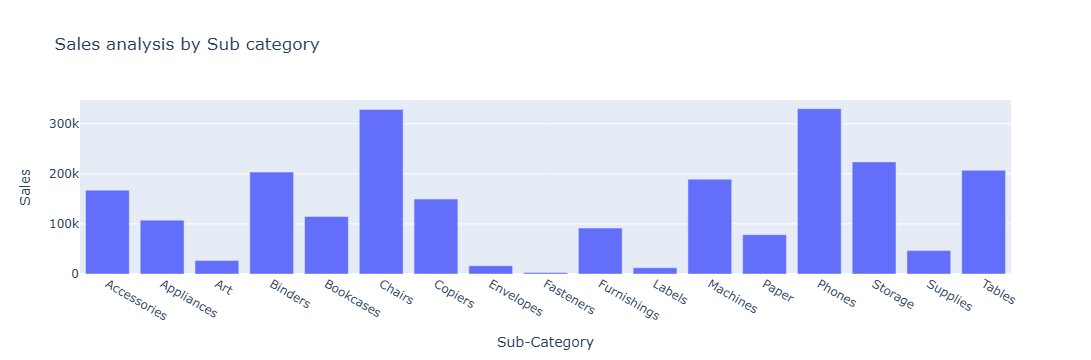

In [49]:
fig = px.bar(sales_by_subcategory,x='Sub-Category',
            y='Sales',
            title="Sales analysis by Sub category")

fig.show()

## Monthly Profit Analysis

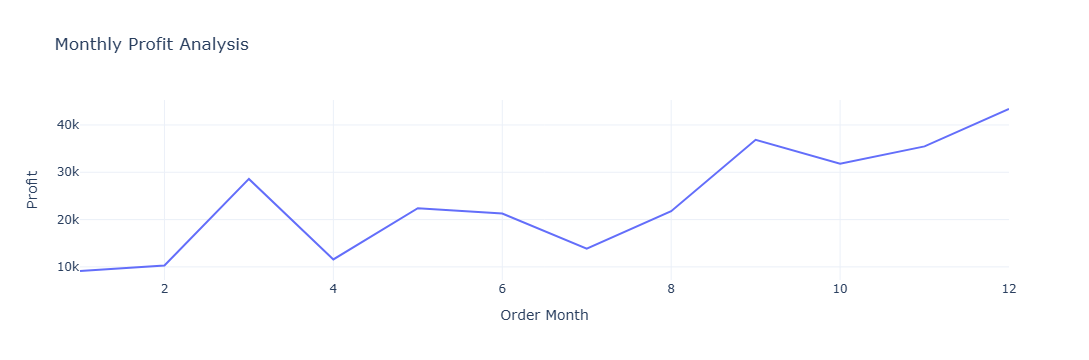

In [96]:
profit_by_month = data.groupby('Order Month')['Profit'].sum().reset_index()

fig = px.line(
    profit_by_month,
    x='Order Month',
    y='Profit',
    title='Monthly Profit Analysis'
)

fig.show()

## Profit by Category

In [60]:
profit_by_category=data.groupby('Category')['Profit'].sum().reset_index()
profit_by_category


,Category,Profit
0,Furniture,18451.2728
1,Office Supplies,122490.8008
2,Technology,145454.9481


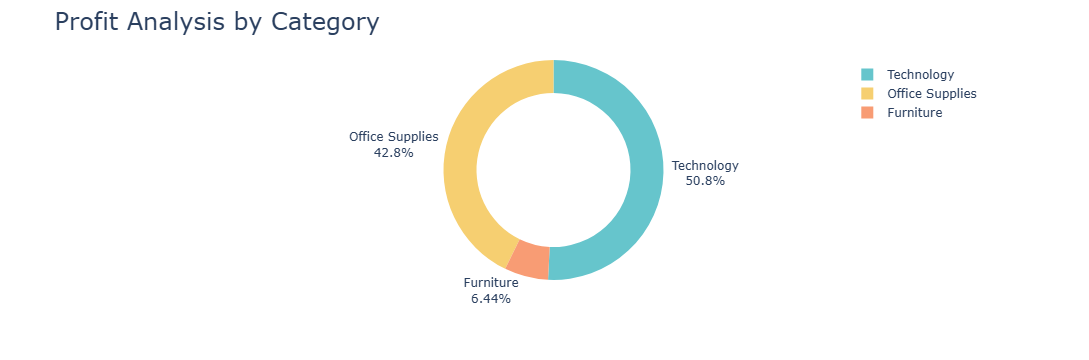

In [64]:
fig2=px.pie(profit_by_category,
            values='Profit',
            names='Category',
            hole=0.7,
            color_discrete_sequence=px.colors.qualitative.Pastel)
fig2.update_traces(textposition='outside', textinfo='percent+label')
fig2.update_layout(title_text='Profit Analysis by Category', title_font= dict(size=24))
fig2.show()

## Profit by Sub-Category

In [59]:
profit_by_subcategory=data.groupby('Sub-Category')['Profit'].sum().reset_index()
profit_by_subcategory

,Sub-Category,Profit
0,Accessories,41936.6357
1,Appliances,18138.0054
2,Art,6527.7870
3,Binders,30221.7633
4,Bookcases,-3472.5560
5,Chairs,26590.1663
6,Copiers,55617.8249
7,Envelopes,6964.1767
8,Fasteners,949.5182
9,Furnishings,13059.1436


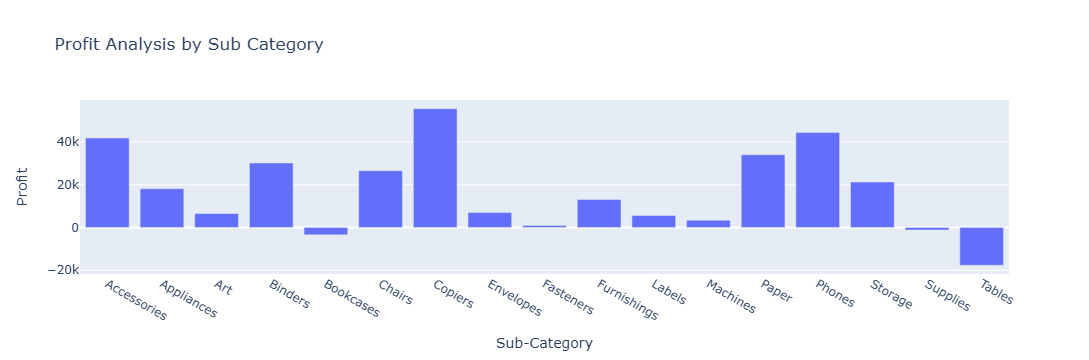

In [67]:
fig = px.bar(profit_by_subcategory,x='Sub-Category',
            y='Profit',
            title="Profit Analysis by Sub Category")

fig.show()

## Sales and Profit - Customer Segment

In [69]:
sales_profit_by_segment= data.groupby('Segment').agg({'Sales':'sum','Profit':'sum'}).reset_index()
sales_profit_by_segment


,Segment,Sales,Profit
0,Consumer,1.161401e+06,134119.2092
1,Corporate,7.061464e+05,91979.1340
2,Home Office,4.296531e+05,60298.6785


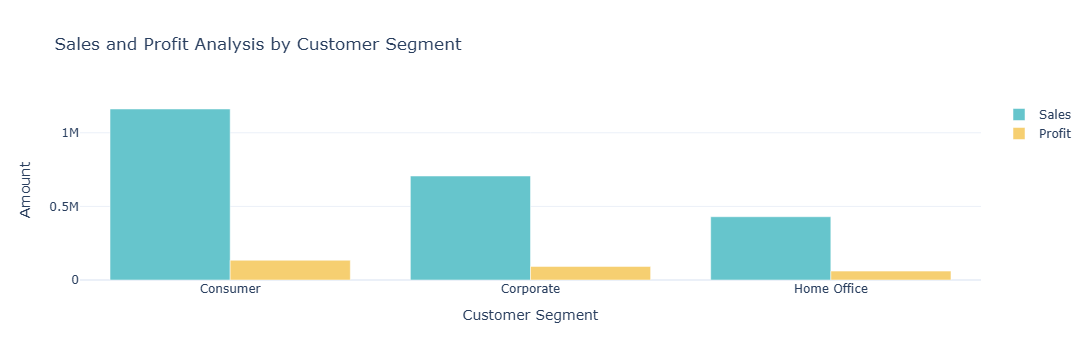

In [84]:
color_palette = colors.qualitative.Pastel

fig = go.Figure()
fig.add_trace(go.Bar(x=sales_profit_by_segment['Segment'], 
                     y=sales_profit_by_segment['Sales'], 
                     name='Sales',
                     marker_color=color_palette[0]))

fig.add_trace(go.Bar(x=sales_profit_by_segment['Segment'], 
                     y=sales_profit_by_segment['Profit'], 
                     name='Profit',
                     marker_color=color_palette[1]))

fig.update_layout(title='Sales and Profit Analysis by Customer Segment',
                  xaxis_title='Customer Segment', yaxis_title='Amount')

fig.show()

## Profit Margin by Customer Segment

In [93]:
sales_profit_by_segment['Profit_Margin'] = (
    sales_profit_by_segment['Profit'] /
    sales_profit_by_segment['Sales']
) * 100

sales_profit_by_segment[['Segment', 'Profit_Margin']]

,Segment,Profit_Margin
0,Consumer,11.548050
1,Corporate,13.025506
2,Home Office,14.034269


## Key Business Insights

1. Sales show clear monthly variation, with the highest sales recorded in November, followed by December and September.

2. Technology is the strongest-performing category in terms of overall sales, making it an important contributor to revenue.

3. The Consumer segment contributes the highest overall sales compared with the Corporate and Home Office segments.

4. Profitability varies across categories and sub-categories, showing that high sales do not always result in equally high profits.

5. Profit margins differ across customer segments, highlighting the importance of evaluating profitability alongside sales when making business decisions.

6. The analysis shows that sales and profit should be evaluated together to identify products and customer segments that generate sustainable business value.